# Step 4 - Build ML Dataset
This notebook turns cleaned flights into the Step 4 training datasets.
It covers split assignment, pointwise supervision, and sequence tensors for the GRU model.


## Modes
`review` reads existing artifacts, `preview` writes a safe subset, and `full` rebuilds the official Step 4 dataset.
For normal review, keep `RUN_STEP4_BUILD = False` and stay in `review` mode.


In [1]:

from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

STEP2_ROOT = PROJECT_ROOT / "artifacts" / "step2_clean"
STEP4_ROOT = PROJECT_ROOT / "artifacts" / "step4_ml_dataset"
STEP4_PREVIEW_ROOT = PROJECT_ROOT / "artifacts" / "step4_ml_dataset_notebook_preview"

RUN_STEP4_BUILD = False
BUILD_MODE = "review"   # review | preview | full
ALLOW_OVERWRITE_OUTPUT_ROOT = False

MAX_PREVIEW_FLIGHTS = 25
MIN_ADSC_POINTS_FOR_ML = 3
TRAIN_FRACTION = 0.70
VAL_FRACTION = 0.15
TEST_FRACTION = 0.15
RANDOM_SEED = 42
WRITE_PER_FLIGHT_OUTPUTS = False
PROGRESS_EVERY = 25

TARGET_STEP4_ROOT = {
    "review": STEP4_ROOT,
    "preview": STEP4_PREVIEW_ROOT,
    "full": STEP4_ROOT,
}[BUILD_MODE]

pd.DataFrame(
    {
        "setting": [
            "run_step4_build",
            "build_mode",
            "allow_overwrite_output_root",
            "step2_root",
            "target_step4_root",
            "max_preview_flights",
            "min_adsc_points_for_ml",
            "train_fraction",
            "val_fraction",
            "test_fraction",
            "random_seed",
            "write_per_flight_outputs",
        ],
        "value": [
            RUN_STEP4_BUILD,
            BUILD_MODE,
            ALLOW_OVERWRITE_OUTPUT_ROOT,
            str(STEP2_ROOT),
            str(TARGET_STEP4_ROOT),
            MAX_PREVIEW_FLIGHTS,
            MIN_ADSC_POINTS_FOR_ML,
            TRAIN_FRACTION,
            VAL_FRACTION,
            TEST_FRACTION,
            RANDOM_SEED,
            WRITE_PER_FLIGHT_OUTPUTS,
        ],
    }
)


,setting,value
0,run_step4_build,False
1,build_mode,review
2,allow_overwrite_output_root,False
3,step2_root,c:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...
4,target_step4_root,c:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...
5,max_preview_flights,25
6,min_adsc_points_for_ml,3
7,train_fraction,0.7
8,val_fraction,0.15
9,test_fraction,0.15


In [2]:

import sys
sys.path.insert(0, str((PROJECT_ROOT / "src").resolve()))
from aero_fusion.step4_build_ml_dataset import Step4Config, run_step4_build_ml_dataset


In [3]:

step4_summary = None

if RUN_STEP4_BUILD:
    if BUILD_MODE == "review":
        raise ValueError("RUN_STEP4_BUILD=True is not allowed with BUILD_MODE='review'. Use 'preview' or 'full'.")
    if not ALLOW_OVERWRITE_OUTPUT_ROOT:
        raise ValueError("Set ALLOW_OVERWRITE_OUTPUT_ROOT = True before rebuilding Step 4 outputs.")

    cfg = Step4Config(
        step2_root=STEP2_ROOT,
        output_root=TARGET_STEP4_ROOT,
        min_adsc_points_for_ml=MIN_ADSC_POINTS_FOR_ML,
        max_flights_to_process=(MAX_PREVIEW_FLIGHTS if BUILD_MODE == "preview" else None),
        train_fraction=TRAIN_FRACTION,
        val_fraction=VAL_FRACTION,
        test_fraction=TEST_FRACTION,
        random_seed=RANDOM_SEED,
        clean_existing_output=True,
        write_per_flight_outputs=WRITE_PER_FLIGHT_OUTPUTS,
        verbose=True,
        progress_every=PROGRESS_EVERY,
    )
    step4_summary = run_step4_build_ml_dataset(cfg)
    step4_summary
else:
    print("RUN_STEP4_BUILD is False -> review mode only, no Step 4 rebuild performed.")


RUN_STEP4_BUILD is False -> review mode only, no Step 4 rebuild performed.


In [4]:

STEP4_CATALOG_ROOT = TARGET_STEP4_ROOT / "catalog"
STEP4_DATASET_ROOT = TARGET_STEP4_ROOT / "dataset"

summary_path = STEP4_CATALOG_ROOT / "step4_summary.json"
flight_splits_path = STEP4_CATALOG_ROOT / "flight_splits.parquet"
issues_path = STEP4_CATALOG_ROOT / "step4_issues.parquet"
point_dataset_path = STEP4_DATASET_ROOT / "point_dataset.parquet"

if not summary_path.exists():
    raise FileNotFoundError(f"Missing Step 4 summary: {summary_path}")

step4_summary_saved = json.loads(summary_path.read_text())
flight_splits = pd.read_parquet(flight_splits_path)
step4_issues = pd.read_parquet(issues_path)
point_dataset = pd.read_parquet(point_dataset_path)

print(json.dumps(step4_summary_saved, indent=2))


{
  "step2_kept_flights_input": 1704,
  "step4_flights_eligible": 1523,
  "step4_flights_failed": 0,
  "point_rows_total": 10242,
  "split_method": "by_icao24",
  "catalog_used": "clean_flights_validated.parquet",
  "split_point_rows": {
    "train": 7220,
    "val": 1234,
    "test": 1788
  },
  "split_flights": {
    "train": 1094,
    "val": 189,
    "test": 240
  },
  "sequence_flights": {
    "train": 1094,
    "val": 189,
    "test": 240
  },
  "sequence_shape": {
    "before_seq": "(N, 64, 6)",
    "after_seq": "(N, 32, 6)",
    "adsc_targets": "(N, 32, 2)",
    "adsc_mask": "(N, 32)"
  },
  "feature_columns": [
    "tau",
    "elapsed_sec_from_before_anchor",
    "gap_duration_sec",
    "gap_duration_minutes",
    "before_anchor_lat",
    "before_anchor_lon",
    "after_anchor_lat",
    "after_anchor_lon",
    "before_anchor_velocity_mps",
    "after_anchor_velocity_mps",
    "before_anchor_heading_deg",
    "after_anchor_heading_deg",
    "before_anchor_geoaltitude_m",
    "af

## Step 4 Executive Summary
These metrics summarize the saved training dataset and split balance.
Use them to confirm that the model input population matches the cleaned flight catalog.


In [5]:

pd.DataFrame(
    {
        "metric": [
            "step2_kept_flights_input",
            "step4_flights_eligible",
            "step4_flights_failed",
            "point_rows_total",
            "train_flights",
            "val_flights",
            "test_flights",
            "train_points",
            "val_points",
            "test_points",
        ],
        "value": [
            step4_summary_saved["step2_kept_flights_input"],
            step4_summary_saved["step4_flights_eligible"],
            step4_summary_saved["step4_flights_failed"],
            step4_summary_saved["point_rows_total"],
            step4_summary_saved["split_flights"]["train"],
            step4_summary_saved["split_flights"]["val"],
            step4_summary_saved["split_flights"]["test"],
            step4_summary_saved["split_point_rows"]["train"],
            step4_summary_saved["split_point_rows"]["val"],
            step4_summary_saved["split_point_rows"]["test"],
        ],
    }
)


,metric,value
0,step2_kept_flights_input,1704
1,step4_flights_eligible,1523
2,step4_flights_failed,0
3,point_rows_total,10242
4,train_flights,1094
5,val_flights,189
6,test_flights,240
7,train_points,7220
8,val_points,1234
9,test_points,1788


## Flight-Level Split Balance
This section checks the train, validation, and test split at the flight level.
The split should stay balanced without leaking aircraft between partitions.


In [6]:

split_by_source = (
    flight_splits.groupby(["source_run", "split"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
split_by_source


split,source_run,test,train,val
0,step1_raw_2023-08-10_to_2023-09-10,11,31,6
1,step1_raw_2023-10-01_to_2023-11-01,16,109,17
2,step1_raw_2023-11-01_to_2023-12-01,24,119,11
3,step1_raw_20230707_20230731,17,58,11
4,step1_raw_2024-02-01_to_2024-03-01,4,16,0
5,step1_raw_2024-04-01_to_2024-05-01,14,50,6
6,step1_raw_2024-05-01_to_2024-06-01,9,39,10
7,step1_raw_2024-07-01_to_2024-08-01,17,78,24
8,step1_raw_2024-08-10_to_2024-09-10,15,78,14
9,step1_raw_2024-09-01_to_2024-10-01,0,15,0


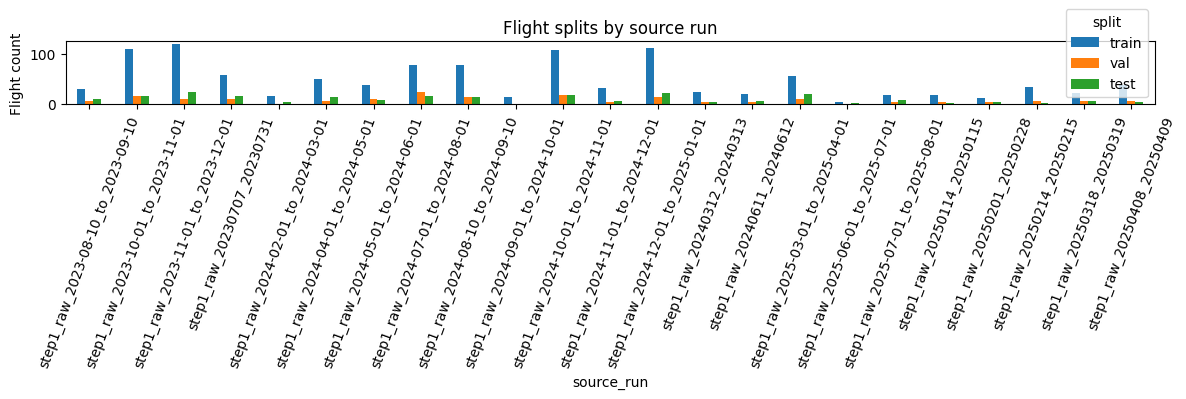

In [7]:

ax = split_by_source.set_index("source_run")[["train", "val", "test"]].plot(kind="bar", figsize=(12,4), title="Flight splits by source run")
ax.set_ylabel("Flight count")
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()


## Point-Level ML Dataset Overview
These summaries describe the tabular supervision built from ADS-C waypoints.
They are the quickest sanity check for feature coverage and target density.


In [8]:

pd.DataFrame(
    {
        "column": point_dataset.columns,
        "dtype": [str(point_dataset[c].dtype) for c in point_dataset.columns],
    }
).head(50)


,column,dtype
0,segment_id,str
1,source_run,str
2,processing_day,object
3,icao24,str
4,adsc_point_index,int64
5,adsc_point_count_clean,int64
6,timestamp,datetime64[us]
7,split,str
8,tau,float64
9,tau_raw,float64


In [9]:

point_dataset[["tau", "gap_duration_minutes", "anchor_distance_m", "baseline_error_m"]].describe().T


,count,mean,std,min,25%,50%,75%,max
tau,10242.0,4.664060e-01,0.248729,2.698062e-03,2.545012e-01,4.558311e-01,6.520938e-01,9.991512e-01
gap_duration_minutes,10242.0,2.536957e+02,57.414961,1.308667e+02,2.103167e+02,2.417667e+02,2.785667e+02,4.718333e+02
anchor_distance_m,10242.0,3.786118e+06,691670.906559,1.689337e+06,3.316258e+06,3.546834e+06,4.093102e+06,6.353693e+06
baseline_error_m,10242.0,1.548612e+05,119574.406720,4.187616e+02,7.182565e+04,1.236037e+05,2.022063e+05,7.785018e+05


## Step 4 Issue Table
This table records flights or samples that could not be converted cleanly.
It helps separate expected exclusions from actual data problems.


In [10]:

step4_issues.head(20)


,segment_id,source_run,issue_type,issue_detail


## Example ML Points
These examples show what one saved training sample looks like after feature assembly.
Use them to verify geometry, normalization, and label alignment.


In [11]:

point_dataset.head(20)


,segment_id,source_run,processing_day,icao24,adsc_point_index,adsc_point_count_clean,timestamp,split,tau,tau_raw,...,after_anchor_geoaltitude_m,anchor_distance_m,anchor_bearing_deg,baseline_lat,baseline_lon,target_lat,target_lon,baseline_error_m,target_residual_east_m,target_residual_north_m
0,20230708_0101e0_115103_124631,step1_raw_20230707_20230731,None,0101e0,0,5,2023-07-08 11:51:03,test,0.085664,0.085664,...,NaN,3.483666e+06,279.383150,57.368685,-15.014600,57.656422,-15.343094,37530.947132,-19718.542464,32030.847942
1,20230708_0101e0_115103_124631,step1_raw_20230707_20230731,None,0101e0,1,5,2023-07-08 12:18:47,test,0.208125,0.208125,...,NaN,3.483666e+06,279.383150,57.519339,-22.142021,58.098793,-22.977562,81247.558087,-49949.081176,64504.770828
2,20230708_0101e0_115103_124631,step1_raw_20230707_20230731,None,0101e0,2,5,2023-07-08 12:32:39,test,0.269355,0.269355,...,NaN,3.483666e+06,279.383150,57.443593,-25.708121,58.101883,-26.815395,98329.206029,-66330.793376,73280.882096
3,20230708_0101e0_115103_124631,step1_raw_20230707_20230731,None,0101e0,3,5,2023-07-08 12:35:47,test,0.283191,0.283191,...,NaN,3.483666e+06,279.383150,57.412570,-26.511223,58.086777,-27.671471,101780.153294,-69563.120535,75052.705829
4,20230708_0101e0_115103_124631,step1_raw_20230707_20230731,None,0101e0,4,5,2023-07-08 12:46:31,test,0.330586,0.330586,...,NaN,3.483666e+06,279.383150,57.267759,-29.249796,57.929020,-30.574436,107866.632338,-79733.053475,73611.596131
5,20230708_040203_105633_115102,step1_raw_20230707_20230731,None,040203,0,5,2023-07-08 10:56:33,train,0.118174,0.118174,...,12031.98,3.288402e+06,279.118244,55.671566,-19.847889,56.014481,-20.372772,50276.559678,-32950.799508,38173.301457
6,20230708_040203_105633_115102,step1_raw_20230707_20230731,None,040203,1,5,2023-07-08 11:23:18,train,0.244284,0.244284,...,12031.98,3.288402e+06,279.118244,55.758445,-26.469279,56.077652,-27.421532,69140.976787,-59647.062368,35534.151280
7,20230708_040203_105633_115102,step1_raw_20230707_20230731,None,040203,2,5,2023-07-08 11:37:03,train,0.309107,0.309107,...,12031.98,3.288402e+06,279.118244,55.664498,-29.868372,55.941696,-30.948658,74215.591671,-67829.713188,30857.698540
8,20230708_040203_105633_115102,step1_raw_20230707_20230731,None,040203,3,5,2023-07-08 11:37:10,train,0.309657,0.309657,...,12031.98,3.288402e+06,279.118244,55.663300,-29.897132,55.939808,-30.978012,74220.029007,-67869.147841,30780.866499
9,20230708_040203_105633_115102,step1_raw_20230707_20230731,None,040203,4,5,2023-07-08 11:51:02,train,0.375029,0.375029,...,12031.98,3.288402e+06,279.118244,55.473243,-33.300110,55.668411,-34.381371,71356.073635,-68222.311072,21726.078298


## Error and Geometry Diagnostics
These diagnostics highlight edge cases in timing, spacing, and interpolation.
They are useful before handing the dataset to model training.


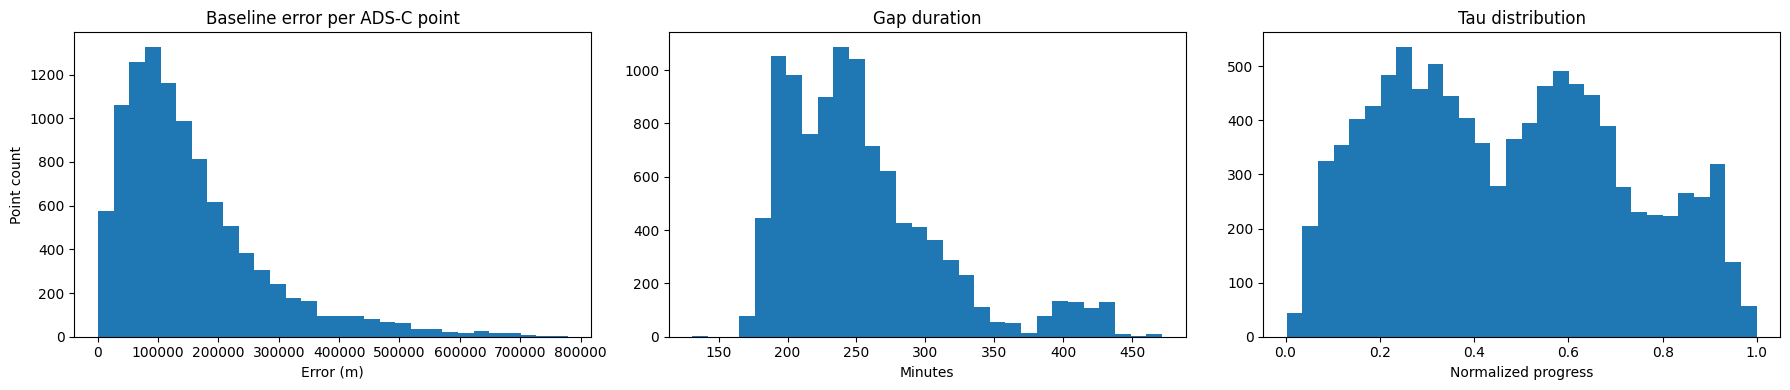

In [12]:

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(point_dataset["baseline_error_m"].dropna(), bins=30)
axes[0].set_title("Baseline error per ADS-C point")
axes[0].set_xlabel("Error (m)")
axes[0].set_ylabel("Point count")

axes[1].hist(point_dataset["gap_duration_minutes"].dropna(), bins=30)
axes[1].set_title("Gap duration")
axes[1].set_xlabel("Minutes")

axes[2].hist(point_dataset["tau"].dropna(), bins=30)
axes[2].set_title("Tau distribution")
axes[2].set_xlabel("Normalized progress")

plt.tight_layout()
plt.show()


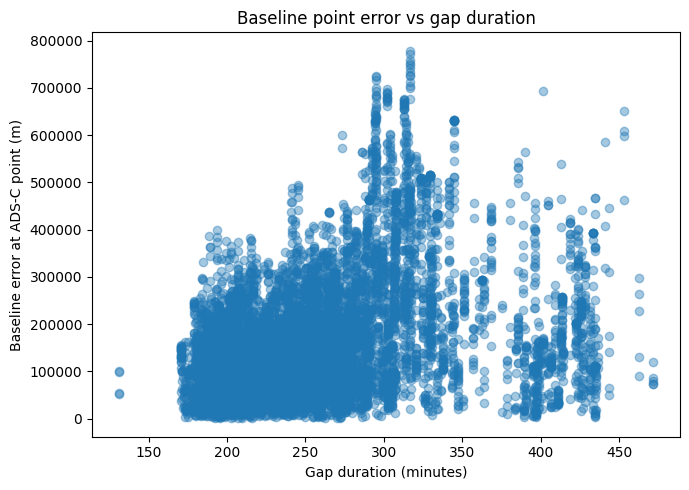

In [13]:

plt.figure(figsize=(7, 5))
plt.scatter(point_dataset["gap_duration_minutes"], point_dataset["baseline_error_m"], alpha=0.4)
plt.xlabel("Gap duration (minutes)")
plt.ylabel("Baseline error at ADS-C point (m)")
plt.title("Baseline point error vs gap duration")
plt.tight_layout()
plt.show()


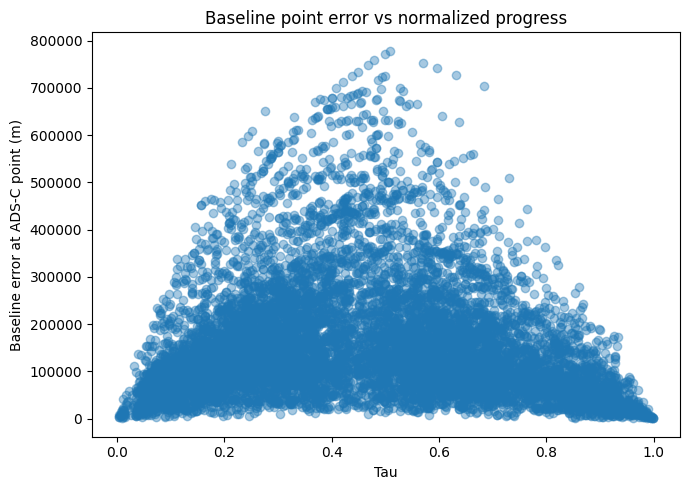

In [14]:

plt.figure(figsize=(7, 5))
plt.scatter(point_dataset["tau"], point_dataset["baseline_error_m"], alpha=0.4)
plt.xlabel("Tau")
plt.ylabel("Baseline error at ADS-C point (m)")
plt.title("Baseline point error vs normalized progress")
plt.tight_layout()
plt.show()


## One Example Flight Point-Cloud
This view shows how the generated ML samples sit along a real flight path.
It is a direct check that the sampling logic preserves trajectory structure.


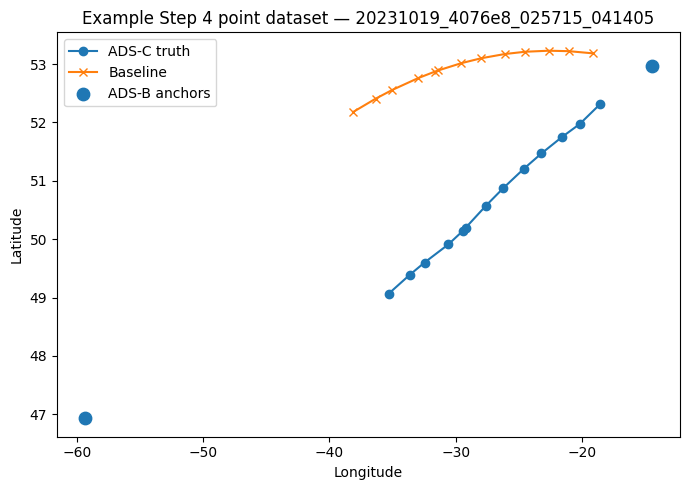

In [15]:

##example_segment_id = point_dataset["segment_id"].iloc[0]
example_segment_id = point_dataset["segment_id"].drop_duplicates().sample(1).iloc[0]

example_points = point_dataset[point_dataset["segment_id"] == example_segment_id].copy()

plt.figure(figsize=(7, 5))
plt.plot(example_points["target_lon"], example_points["target_lat"], marker="o", label="ADS-C truth")
plt.plot(example_points["baseline_lon"], example_points["baseline_lat"], marker="x", label="Baseline")
plt.scatter(
    [example_points["before_anchor_lon"].iloc[0], example_points["after_anchor_lon"].iloc[0]],
    [example_points["before_anchor_lat"].iloc[0], example_points["after_anchor_lat"].iloc[0]],
    s=80,
    label="ADS-B anchors",
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"Example Step 4 point dataset — {example_segment_id}")
plt.legend()
plt.tight_layout()
plt.show()


## Step 4 Output Guide
The source of truth is the saved catalog and dataset files under `artifacts/step4_ml_dataset`.
Keep the notebook in review mode unless you intentionally want to rebuild Step 4 artifacts.
